# 01 - EDA

Cells that ran **once**, to justify a decision. Nothing here needs to run again
when new data arrives, so nothing here is imported by `src/`.

Original cells: 2-7, 9-13 (inspection half), 14-22.
Cells 1, 8, 13 (the drop itself) and 23 moved to `disease_pred.data`.

Notebooks import from `src/`, never the reverse.

In [1]:
# --- make src/ importable ------------------------------------------------
import sys
from pathlib import Path

_here = Path.cwd()
for _p in (_here, *_here.parents):
    if (_p / "src" / "disease_pred").is_dir():
        sys.path.insert(0, str(_p / "src"))
        PROJECT = _p
        break
else:
    raise RuntimeError("could not locate src/disease_pred above %s" % _here)
print("project root:", PROJECT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from disease_pred.config import PARAMS
from disease_pred.data import load_raw, clean, select_features

pd.set_option("display.width", 140)

project root: e:\AI_ML\Prac\Logistic Regression\disease prediction project


In [8]:
sum(PARAMS["features"]["roles"].values(),[])

['age',
 'trestbps',
 'chol',
 'thalach',
 'oldpeak',
 'sex',
 'fbs',
 'cp',
 'restecg',
 'thal',
 'exang',
 'slope',
 'ca']



`disease_pred.data.load_raw()`. `COLS` and `FILES` live in `params.yaml`.

In [6]:
raw = load_raw()
print(raw.shape)
raw['site'].value_counts()

(920, 15)


site
cleveland      303
hungary        294
va             200
switzerland    123
Name: count, dtype: int64

In [7]:
raw.head()
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  num       920 non-null    int64  
 14  site      920 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 107.9+ KB


In [8]:
def bin_values(df,id_thresh=0.95,cat_thresh=5,force_cat=None,datetime_cols=None):
    n=len(df)
    buckets={'id':[],'datetime':[],'categorical':[],'dis_num':[],'cont':[],'binary':[]}
    datetime_cols=set(datetime_cols or [])
    force_cat=set(force_cat or [])

    for col in df.columns:
        if col == 'site':continue

        s=df[col]
        nunique=s.nunique()

        if pd.api.types.is_datetime64_any_dtype(s) or col in datetime_cols:
            buckets['datetime'].append(col)
            continue
        is_id_like_dtype=pd.api.types.is_integer_dtype(s) or pd.api.types.is_numeric_dtype(s)
        if is_id_like_dtype and n>=0 and nunique/n>id_thresh:
            buckets['id'].append(col)
            continue
        if col in force_cat:
            buckets['categorical'].append(col)
            continue
        if nunique==2:
            buckets['binary'].append(col)
            continue
        if pd.api.types.is_numeric_dtype(s) and nunique >cat_thresh:
            buckets['cont'].append(col)
            continue
        else:
            buckets['categorical'].append(col)
    return buckets

buckets=bin_values(raw)
buckets

{'id': [],
 'datetime': [],
 'categorical': ['cp', 'restecg', 'slope', 'ca', 'thal', 'num'],
 'dis_num': [],
 'cont': ['age', 'trestbps', 'chol', 'thalach', 'oldpeak'],
 'binary': ['sex', 'fbs', 'exang']}

In [9]:
raw.describe()[buckets['cont']].T

,count,mean,std,min,25%,50%,75%,max
age,920.0,53.510870,9.424685,28.0,47.0,54.0,60.0,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.0,130.0,140.0,200.0
chol,890.0,199.130337,110.780810,0.0,175.0,223.0,268.0,603.0
thalach,865.0,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.0,0.5,1.5,6.2


In [10]:
for c in buckets['cont']:
    print(c,(raw[c]==0).sum(),(raw[c]<0).sum(),(raw[c] > raw[c].quantile(.999)*3).sum())

age 0 0 0
trestbps 1 0 0
chol 172 0 0
thalach 0 0 0
oldpeak 370 12 0


In [7]:
raw['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [11]:
df = clean(raw, drop_duplicates=False)

for c in PARAMS['data']['zero_is_missing']:
    n = (raw[c] == 0).sum()
    print(f' for {c} changin {n} values to NaN')

print(f'prevalance {df["target"].mean():.2f}')
df['target'].value_counts()

 for chol changin 172 values to NaN
 for trestbps changin 1 values to NaN
prevalance 0.55


target
1    509
0    411
Name: count, dtype: int64

In [12]:
def audit(df):
    return pd.DataFrame({
        'null values':df.isnull().sum(),
        'null_%':df.isnull().mean()*100,
        'unique':df.nunique(),
        'unique_%':(df.nunique()/len(df)*100),
        'dtype':df.dtypes.astype(str),
        'zero':(df==0).sum(),
        'top_value':df.mode().iloc[0],
        'top_freq_%':((df.apply(lambda g:g.value_counts(normalize=True,dropna=False).iloc[0]))*100),
        'sample':df.iloc[0]
    })
audit(df)

,null values,null_%,unique,unique_%,dtype,zero,top_value,top_freq_%,sample
age,0,0.000000,50,5.434783,float64,0,54.0,5.543478,63.0
sex,0,0.000000,2,0.217391,float64,194,1.0,78.913043,1.0
cp,0,0.000000,4,0.434783,float64,0,4.0,53.913043,1.0
trestbps,60,6.521739,60,6.521739,float64,0,120.0,14.239130,145.0
chol,202,21.956522,216,23.478261,float64,0,220.0,21.956522,233.0
fbs,90,9.782609,2,0.217391,float64,692,0.0,75.217391,1.0
restecg,2,0.217391,3,0.326087,float64,551,0.0,59.891304,2.0
thalach,55,5.978261,119,12.934783,float64,0,150.0,5.978261,150.0
exang,55,5.978261,2,0.217391,float64,528,0.0,57.391304,0.0
oldpeak,62,6.739130,53,5.760870,float64,370,0.0,40.217391,2.3


In [13]:
#MCAR MNAR MAR
missing_values=df.groupby('site').apply(lambda g: g.isna().mean()*100,include_groups=False)
missing_values.loc[:,(missing_values.max()>0)]

,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
site,,,,,,,,,,
cleveland,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.320132,0.660066
hungary,0.340136,7.823129,2.721088,0.340136,0.340136,0.340136,0.000000,64.625850,98.979592,90.476190
switzerland,1.626016,100.000000,60.975610,0.813008,0.813008,0.813008,4.878049,13.821138,95.934959,42.276423
va,28.500000,28.000000,3.500000,0.000000,26.500000,26.500000,28.000000,51.000000,99.000000,83.000000


In [15]:
pd.crosstab(df['site'],df['target'],normalize='index')

target,0,1
site,,
cleveland,0.541254,0.458746
hungary,0.639456,0.360544
switzerland,0.065041,0.934959
va,0.255000,0.745000




reading above tables side by side , for
clv: balance data , full clinical workup,  more general population
swt: very high prev, most likely only the diseased were included in the trials . and chol is fully missing , ca ~ 95
va: moderate missing across board, ca heavily missing . prev suggests same case as swt , only less extreme.
hung: slope ca, thal almost missing entirely , but others are relatively complete. prev is lowest. missingness doesnt track prev the way swt does.

key takeaways
missingness and prev vary strongly by site. in case of swz and va they move together
so missingness is not at random,so a column like ca being missing might itself be info about site.
if we build ' is this missing ' indicator then that may just be end up being proxy for site. the model could just learn 'missing> prob singapore > probably diseased' , whihc is not good for generalisation

so argument for checking performance isnt driven by one or 2 sites, and using stratified train test split by site.

> **-> model card.** This paragraph is the source of the cross-site caveat in `reports/model_card.md`.

In [14]:
df[df.duplicated(keep=False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,site,target
404,49.0,0.0,2.0,110.0,NaN,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,hungary,0
405,49.0,0.0,2.0,110.0,NaN,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,hungary,0
859,58.0,1.0,3.0,150.0,219.0,0.0,1.0,118.0,1.0,0.0,NaN,NaN,NaN,va,1
907,58.0,1.0,3.0,150.0,219.0,0.0,1.0,118.0,1.0,0.0,NaN,NaN,NaN,va,1


In [16]:
df = clean(raw)          # same call, this time with the dedup
print(df.duplicated().sum())
df.shape

0


(918, 15)

## plots

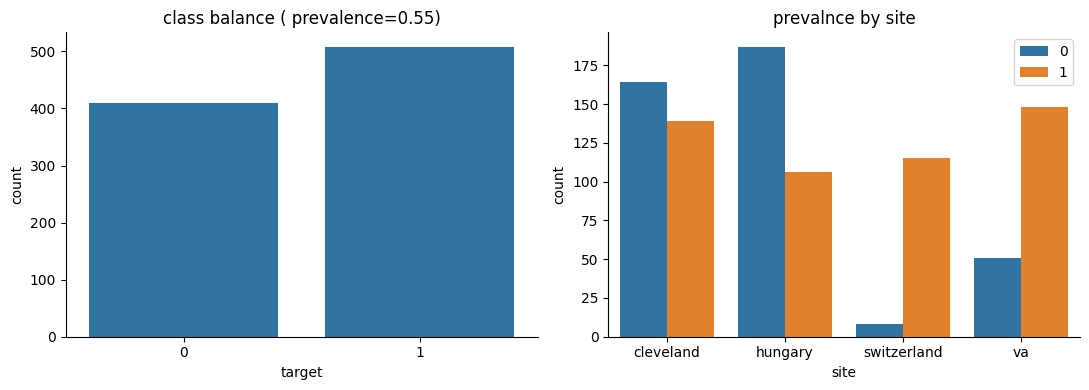

In [17]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
sns.countplot(df,x='target',ax=axes[0])
axes[0].set_title(f'class balance ( prevalence={df.target.mean():.2f})')
sns.countplot(df,x='site',hue='target',ax=axes[1])
axes[1].set_title('prevalnce by site')
plt.legend(loc='best')
plt.tight_layout()
sns.despine(top=True,right=True)

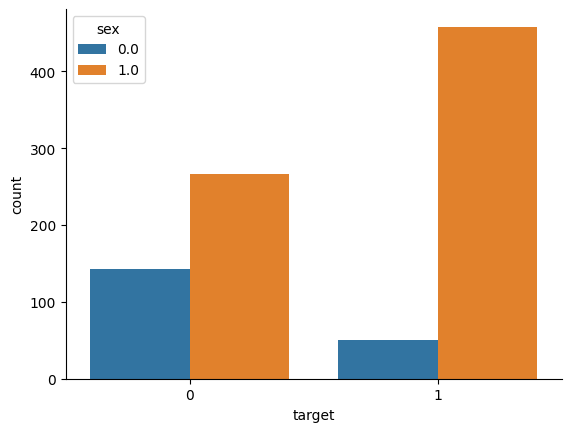

In [21]:
sns.countplot(df,x='target',hue='sex')
sns.despine(top=True,right=True)

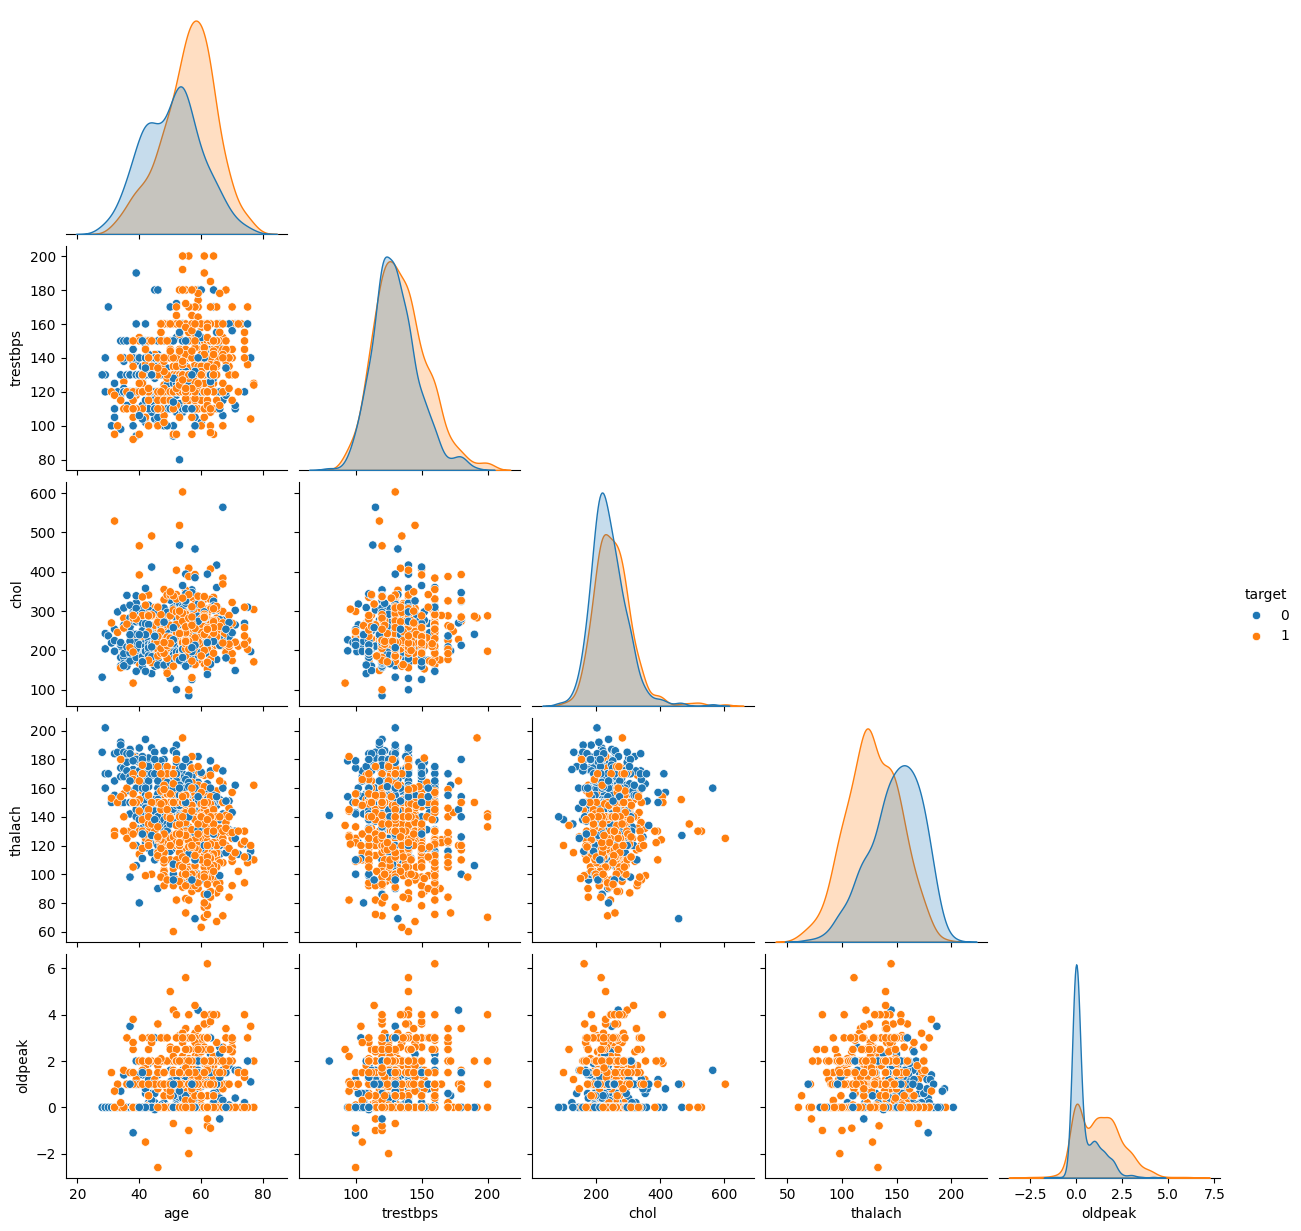

In [20]:
df_pairplot=df[buckets['cont']+['target']]
sns.pairplot(df_pairplot,kind='scatter',hue='target',corner=True)

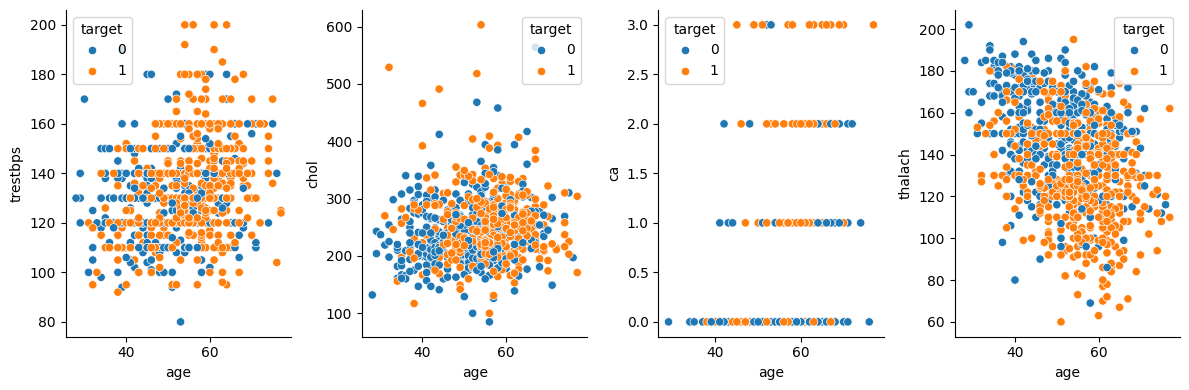

In [23]:
fig,axes=plt.subplots(1,4,figsize=(12,4))
sns.scatterplot(data=df,x='age',y='trestbps',hue='target',ax=axes[0])
sns.scatterplot(data=df,x='age',y='chol',hue='target',ax=axes[1])
sns.scatterplot(data=df,x='age',y='ca',hue='target',ax=axes[2])
sns.scatterplot(data=df,x='age',y='thalach',hue='target',ax=axes[3])
[ax.spines[['top','right']].set_visible(False) for ax in fig.axes]
fig.tight_layout()

[None, None, None, None, None]

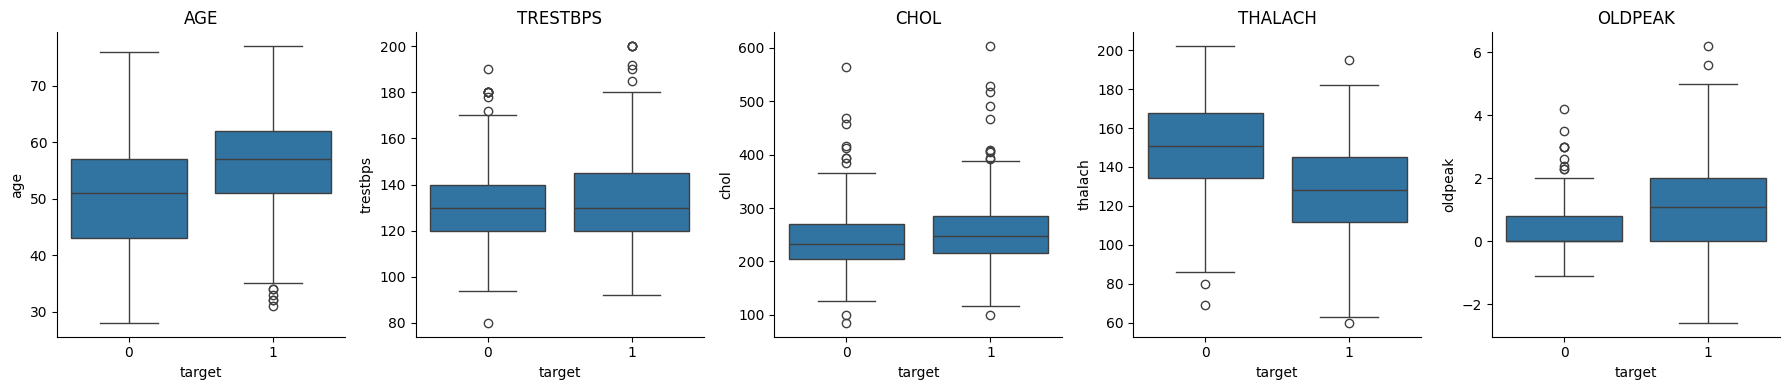

In [24]:
fig,axes=plt.subplots(1,len(buckets['cont']),figsize=(18,4))
for ax, col in zip(axes,buckets['cont']):
    sns.boxplot(df,x='target',y=col,patch_artist=True,ax=ax)
    ax.set_title(col.upper())
plt.tight_layout()
[ax.spines[['top','right']].set_visible(False) for ax in fig.axes]

<Axes: >

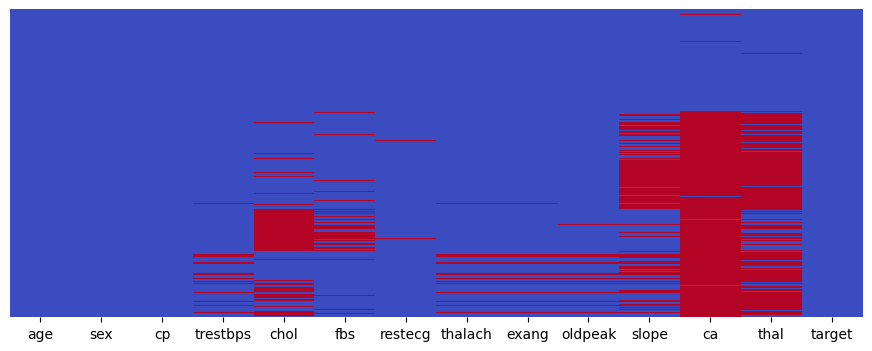

In [26]:
#missing map
plt.figure(figsize=(11,4))
sns.heatmap(df.sort_values('site').drop(columns='site').isna(),cmap='coolwarm',yticklabels=False,cbar=False)

<Axes: >

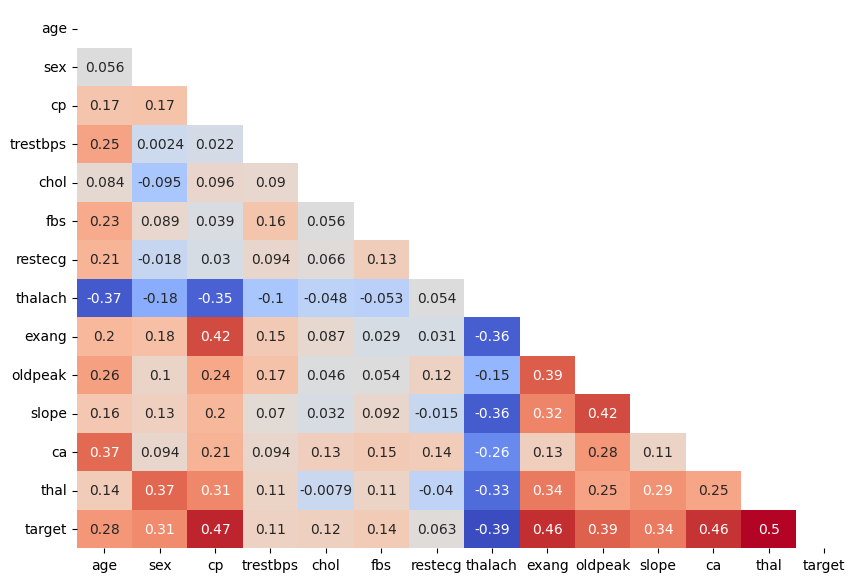

In [20]:
plt.figure(figsize=(10,7))
corr=df.drop('site',axis=1).corr()
mask=np.triu(np.ones_like(corr))
sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',cbar=False)

In [ ]:
(df['exang'].isna()==df['thalach'].isna()).mean()
#both come form same test and carry the same missing ness signal

np.float64(1.0)

## `data.select_features()`



In [27]:
spec_full_frame = select_features(df)      # what the notebook did (leaky)
print('dropped:', spec_full_frame['dropped_high_missing'])
print('numeric    ', spec_full_frame['numeric'])
print('binary     ', spec_full_frame['binary'])
print('CATEGORICAL', spec_full_frame['categorical'])
print('\nn features:', len(spec_full_frame['features']))

dropped: ['thal', 'slope', 'ca']
numeric     ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
binary      ['sex', 'fbs']
CATEGORICAL ['cp', 'restecg', 'exang']

n features: 10
